In [1]:
import sys
from pathlib import Path
import numpy as np

import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import sys
from pathlib import Path
import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [3]:
MATLAB_DIR = PROJECT_ROOT / "data" / "matlab"
MATLAB_DIR.mkdir(parents=True, exist_ok=True)

print("MATLAB_DIR:", MATLAB_DIR)
print("MATLAB_DIR exists:", MATLAB_DIR.exists())

mat_files = sorted(MATLAB_DIR.glob("*.mat"))

print("\nMAT files found:")
for i, p in enumerate(mat_files):
    print(f"{i}: {p.name}")

if len(mat_files) == 0:
    raise FileNotFoundError(f"No .mat file found in {MATLAB_DIR}")

# Si tu as seulement un .mat, il le prend automatiquement.
# Si tu en as plusieurs, change l'index ici.
MATLAB_RESULT_PATH = mat_files[0]

PY_TIMTRACK_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
PY_KLT_NPZ = PROJECT_ROOT / "results" / "klt_sequence_features_arrays.npz"
PY_UTT_NPZ = PROJECT_ROOT / "results" / "ultratimtrack_geometric_kalman_features_arrays.npz"

RESULTS_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_SUMMARY_CSV = RESULTS_DIR / "matlab_vs_python_utt_summary_metrics.csv"
OUT_ALIGNED_NPZ = RESULTS_DIR / "matlab_vs_python_utt_aligned_arrays.npz"

print("\nUsing MATLAB_RESULT_PATH:", MATLAB_RESULT_PATH)
print("PY_UTT_NPZ:", PY_UTT_NPZ)
print("RESULTS_DIR:", RESULTS_DIR)

MATLAB_DIR: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab
MATLAB_DIR exists: True

MAT files found:
0: slow_low_01_DOWN_tracked_Q=001.mat

Using MATLAB_RESULT_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
PY_UTT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features_arrays.npz
RESULTS_DIR: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison


In [4]:
print("MATLAB_RESULT_PATH:", MATLAB_RESULT_PATH)
print("Exists:", MATLAB_RESULT_PATH.exists())

if not MATLAB_RESULT_PATH.exists():
    print("\nAvailable .mat files in project:")
    for p in PROJECT_ROOT.rglob("*.mat"):
        print("-", p)
else:
    print("MATLAB file found OK.")

MATLAB_RESULT_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
Exists: True
MATLAB file found OK.


In [5]:

py_tim = np.load(PY_TIMTRACK_NPZ, allow_pickle=True)
py_klt = np.load(PY_KLT_NPZ, allow_pickle=True)
py_utt = np.load(PY_UTT_NPZ, allow_pickle=True)

print("Python UTT-like keys:")
for key in py_utt.files:
    print(" -", key, py_utt[key].shape)

Python UTT-like keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - utt_states (2667, 4)
 - utt_segments (2667, 4)
 - utt_sup_attachments (2667, 2)
 - utt_deep_attachments (2667, 2)
 - utt_fascicle_length_px (2667,)
 - utt_fascicle_angle_deg (2667,)
 - utt_deep_apo_angle_deg (2667,)
 - utt_pennation_angle_deg (2667,)
 - utt_uncertainty (2667, 4)
 - utt_gain_diag (2667, 4)
 - utt_innovation_norm (2667,)
 - used_timtrack_measurement (2667,)
 - used_klt_prediction (2667,)
 - timtrack_length_px (2667,)
 - timtrack_pennation_angle_deg (2667,)
 - klt_length_px (2667,)
 - klt_pennation_angle_deg (2667,)
 - timtrack_segments (2667, 4)
 - klt_segments (2667, 4)


In [6]:
py_frame = py_utt["frame"].astype(int)
py_time = py_utt["time_s"].astype(np.float32)

py_utt_length_px = py_utt["utt_fascicle_length_px"].astype(np.float32)
py_utt_pennation = py_utt["utt_pennation_angle_deg"].astype(np.float32)
py_utt_fascicle_angle = py_utt["utt_fascicle_angle_deg"].astype(np.float32)

print("Python arrays loaded.")
print("N frames:", len(py_frame))
print("Time range:", np.nanmin(py_time), "to", np.nanmax(py_time), "s")
print("Python length unit: pixels")

Python arrays loaded.
N frames: 2667
Time range: 0.0 to 79.96161 s
Python length unit: pixels


In [7]:
from pathlib import Path

try:
    from scipy.io import loadmat
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import h5py
    H5PY_AVAILABLE = True
except ImportError:
    H5PY_AVAILABLE = False


def load_matlab_file(path):
    """
    Load MATLAB .mat file.

    Works for normal .mat files through scipy.io.loadmat.
    MATLAB v7.3 files may require h5py.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"MATLAB file not found:\n{path}")

    if SCIPY_AVAILABLE:
        try:
            data = loadmat(path, simplify_cells=True)
            data = {k: v for k, v in data.items() if not k.startswith("__")}
            print("Loaded with scipy.io.loadmat")
            return data
        except NotImplementedError:
            print("scipy could not load this file. Trying h5py...")
        except Exception as exc:
            print("scipy loadmat failed:", exc)
            print("Trying h5py...")

    if H5PY_AVAILABLE:
        data = {}

        with h5py.File(path, "r") as f:
            def recursively_load(name, obj):
                if isinstance(obj, h5py.Dataset):
                    data[name] = np.array(obj)

            f.visititems(recursively_load)

        print("Loaded with h5py")
        return data

    raise ImportError("Need scipy or h5py to load MATLAB .mat files.")


mat = load_matlab_file(MATLAB_RESULT_PATH)

print("\nTop-level MATLAB keys:")
for key in mat.keys():
    print(" -", key, type(mat[key]))

Loaded with scipy.io.loadmat

Top-level MATLAB keys:
 - TrackingData <class 'dict'>
 - Fdat <class 'dict'>


In [8]:
def summarize_mat_value(name, value, max_depth=2, depth=0):
    indent = "  " * depth

    if isinstance(value, dict):
        print(f"{indent}{name}: dict with keys {list(value.keys())[:30]}")
        if depth < max_depth:
            for k, v in value.items():
                summarize_mat_value(k, v, max_depth=max_depth, depth=depth + 1)

    elif isinstance(value, np.ndarray):
        print(f"{indent}{name}: ndarray shape={value.shape}, dtype={value.dtype}")

    elif isinstance(value, (list, tuple)):
        print(f"{indent}{name}: {type(value).__name__}, len={len(value)}")
        if len(value) > 0 and depth < max_depth:
            summarize_mat_value(name + "[0]", value[0], max_depth=max_depth, depth=depth + 1)

    else:
        print(f"{indent}{name}: {type(value).__name__} = {str(value)[:100]}")


print("MATLAB variable summary:")
for key, value in mat.items():
    summarize_mat_value(key, value, max_depth=2)

MATLAB variable summary:
TrackingData: dict with keys ['res', 'start_frame', 'NumFrames', 'ProcessingTime', 'BlockSize', 'Parallel', 'info', 'S', 'D']
  res: float = 50.7
  start_frame: int = 1
  NumFrames: int = 2666
  ProcessingTime: ndarray shape=(2,), dtype=float64
  BlockSize: ndarray shape=(2,), dtype=uint8
  Parallel: int = 1
  info: ndarray shape=(1,), dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]
  S: ndarray shape=(1,), dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]
  D: ndarray shape=(1,), dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]
Fdat: dict with keys ['R', 'geofeatures', 'Region']
  R: ndarray shape=(5,), dtype=float64
  geofeatures: list, len=2666
    geofeatures[0]: dict with keys ['alphas', 'gamma', 'betha', 'thickness', 'faslen', 'alpha', 'phi', 'fat_thickness', 'ws', 'hs', 'brightness', 'extrapolated_fraction', 'analysis_duration', 'super_coef', 'deep_coef', 'fas_coef', 'y', 'x', 'super_pos', 'deep_pos']
  Region: dict with 

In [9]:
def get_nested(data, path):
    """
    Get nested variable using dot path.
    Example:
        get_nested(mat, "Fdat.Region.FL")
    """
    parts = path.split(".")
    obj = data

    for part in parts:
        if isinstance(obj, dict):
            if part not in obj:
                raise KeyError(f"Key '{part}' not found. Available: {list(obj.keys())}")
            obj = obj[part]
        else:
            if not hasattr(obj, part):
                raise KeyError(f"Object has no attribute '{part}'")
            obj = getattr(obj, part)

    return obj


def to_1d_float(x):
    """
    Convert MATLAB-loaded array/list/scalar to 1D float numpy array.
    """
    arr = np.asarray(x)
    arr = np.squeeze(arr)

    if arr.ndim > 1:
        arr = arr.reshape(-1)

    return arr.astype(np.float32)

In [10]:
mat_time = to_1d_float(get_nested(mat, "Fdat.Region.Time"))

mat_utt_length = to_1d_float(get_nested(mat, "Fdat.Region.FL"))
mat_utt_pennation = to_1d_float(get_nested(mat, "Fdat.Region.PEN"))
mat_utt_fascicle_angle = to_1d_float(get_nested(mat, "Fdat.Region.ANG"))

mat_frame = np.arange(len(mat_utt_length))

print("MATLAB UltraTimTrack final arrays:")
print("mat_time:", mat_time.shape, mat_time[:3])
print("mat_utt_length:", mat_utt_length.shape, mat_utt_length[:3])
print("mat_utt_pennation:", mat_utt_pennation.shape, mat_utt_pennation[:3])
print("mat_utt_fascicle_angle:", mat_utt_fascicle_angle.shape, mat_utt_fascicle_angle[:3])

MATLAB UltraTimTrack final arrays:
mat_time: (2666,) [0.02999309 0.05998618 0.08997928]
mat_utt_length: (2666,) [72.30705  72.304146 72.30361 ]
mat_utt_pennation: (2666,) [20.387455 20.388172 20.38837 ]
mat_utt_fascicle_angle: (2666,) [18.520489 18.520433 18.51992 ]


In [11]:
tracking_res = get_nested(mat, "TrackingData.res")

print("TrackingData.res:", tracking_res)
print("Interprétation probable: profondeur image en mm")

print("\nMATLAB length first values:")
print(mat_utt_length[:5])

print("\nPython length first values in pixels:")
print(py_utt_length_px[:5])

TrackingData.res: 50.7
Interprétation probable: profondeur image en mm

MATLAB length first values:
[72.30705  72.304146 72.30361  72.30634  72.31269 ]

Python length first values in pixels:
[805.5336  806.7926  805.76483 797.26935 805.5117 ]


In [12]:
# Approximation: image depth in mm divided by full frame height in pixels.
# Adjust IMAGE_DEPTH_PIXELS if MATLAB used a cropped ultrasound image height.

try:
    import cv2

    VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    ret, frame0 = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError("Could not read first video frame")

    frame_height_px = frame0.shape[0]

except Exception as exc:
    print("Could not read video. Using fallback image height.")
    print(exc)
    frame_height_px = 512  # fallback; adjust manually if needed

IMAGE_DEPTH_MM = float(tracking_res)
IMAGE_DEPTH_PIXELS = frame_height_px

MM_PER_PIXEL = IMAGE_DEPTH_MM / IMAGE_DEPTH_PIXELS

py_utt_length_mm = py_utt_length_px * MM_PER_PIXEL

print("IMAGE_DEPTH_MM:", IMAGE_DEPTH_MM)
print("IMAGE_DEPTH_PIXELS:", IMAGE_DEPTH_PIXELS)
print("MM_PER_PIXEL:", MM_PER_PIXEL)

print("\nPython length first values converted to mm:")
print(py_utt_length_mm[:5])

IMAGE_DEPTH_MM: 50.7
IMAGE_DEPTH_PIXELS: 562
MM_PER_PIXEL: 0.09021352313167261

Python length first values converted to mm:
[72.67003 72.7836  72.69088 71.92448 72.66805]


In [13]:
n_common = min(len(py_frame), len(mat_frame))

print("Python N:", len(py_frame))
print("MATLAB N:", len(mat_frame))
print("Common N:", n_common)

sl = slice(0, n_common)

# Time
a_py_time = py_time[sl]
a_mat_time = mat_time[sl]

# Use Python time for plots by default.
a_time = a_py_time

# Python aligned
a_py_utt_length_px = py_utt_length_px[sl]
a_py_utt_length_mm = py_utt_length_mm[sl]
a_py_utt_pennation = py_utt_pennation[sl]
a_py_utt_fascicle_angle = py_utt_fascicle_angle[sl]

# MATLAB aligned
a_mat_utt_length = mat_utt_length[sl]
a_mat_utt_pennation = mat_utt_pennation[sl]
a_mat_utt_fascicle_angle = mat_utt_fascicle_angle[sl]

print("Alignment done.")
print("First MATLAB time:", a_mat_time[:3])
print("First Python time:", a_py_time[:3])

Python N: 2667
MATLAB N: 2666
Common N: 2666
Alignment done.
First MATLAB time: [0.02999309 0.05998618 0.08997928]
First Python time: [0.        0.0299931 0.0599862]


In [14]:
def valid_pair(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask], mask


def compute_metrics(reference, estimate):
    """
    reference = MATLAB
    estimate = Python
    """
    ref, est, mask = valid_pair(reference, estimate)

    if len(ref) == 0:
        return {
            "n": 0,
            "bias": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "corr": np.nan,
        }

    diff = est - ref

    if len(ref) > 1 and np.nanstd(ref) > 0 and np.nanstd(est) > 0:
        corr = np.corrcoef(ref, est)[0, 1]
    else:
        corr = np.nan

    return {
        "n": int(len(ref)),
        "bias": float(np.nanmean(diff)),
        "mae": float(np.nanmean(np.abs(diff))),
        "rmse": float(np.sqrt(np.nanmean(diff ** 2))),
        "corr": float(corr),
    }


def print_metrics(name, reference, estimate):
    m = compute_metrics(reference, estimate)
    print(f"\n{name}")
    print("  n   :", m["n"])
    print("  bias:", m["bias"])
    print("  MAE :", m["mae"])
    print("  RMSE:", m["rmse"])
    print("  corr:", m["corr"])
    return m

In [15]:
metrics = {}

metrics["utt_length_mm"] = print_metrics(
    "UltraTimTrack length: MATLAB mm vs Python converted mm",
    a_mat_utt_length,
    a_py_utt_length_mm,
)

metrics["utt_pennation"] = print_metrics(
    "UltraTimTrack pennation: MATLAB vs Python",
    a_mat_utt_pennation,
    a_py_utt_pennation,
)

metrics["utt_fascicle_angle"] = print_metrics(
    "UltraTimTrack fascicle angle: MATLAB vs Python",
    a_mat_utt_fascicle_angle,
    a_py_utt_fascicle_angle,
)


UltraTimTrack length: MATLAB mm vs Python converted mm
  n   : 2666
  bias: 17.12135850515745
  MAE : 17.121726805163966
  RMSE: 19.063713485403177
  corr: 0.5710090481476722

UltraTimTrack pennation: MATLAB vs Python
  n   : 2666
  bias: -8.563590290487394
  MAE : 8.563703812787342
  RMSE: 10.137568563942855
  corr: -0.6640260054937195

UltraTimTrack fascicle angle: MATLAB vs Python
  n   : 2666
  bias: -8.975239061540172
  MAE : 8.9754179230509
  RMSE: 10.689861565888803
  corr: -0.7671421576111253


In [17]:
rows = []

for name, m in metrics.items():
    row = {"comparison": name}
    row.update(m)
    rows.append(row)

try:
    import pandas as pd

    df_metrics = pd.DataFrame(rows)
    df_metrics.to_csv(OUT_SUMMARY_CSV, index=False)

    display(df_metrics)
    print("Saved:", OUT_SUMMARY_CSV)

except ImportError:
    print("pandas is not installed. Printing rows instead:")
    for row in rows:
        print(row)

,comparison,n,bias,mae,rmse,corr
0,utt_length_mm,2666,17.121359,17.121727,19.063713,0.571009
1,utt_pennation,2666,-8.563590,8.563704,10.137569,-0.664026
2,utt_fascicle_angle,2666,-8.975239,8.975418,10.689862,-0.767142


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/matlab_vs_python_utt_summary_metrics.csv


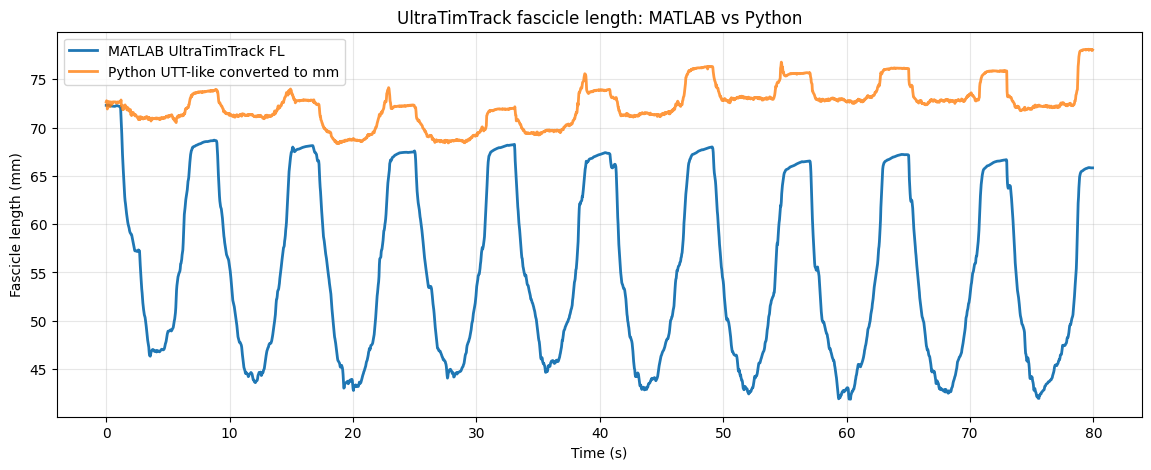

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

plt.plot(a_time, a_mat_utt_length, "-", linewidth=2, label="MATLAB UltraTimTrack FL")
plt.plot(a_time, a_py_utt_length_mm, "-", linewidth=2, alpha=0.8, label="Python UTT-like converted to mm")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle length (mm)")
plt.title("UltraTimTrack fascicle length: MATLAB vs Python")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

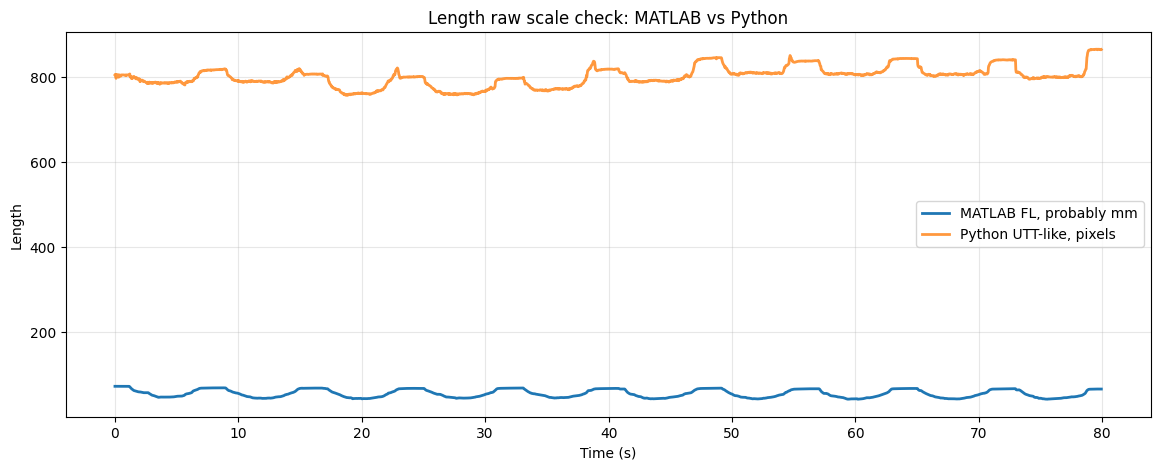

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(a_time, a_mat_utt_length, "-", linewidth=2, label="MATLAB FL, probably mm")
plt.plot(a_time, a_py_utt_length_px, "-", linewidth=2, alpha=0.8, label="Python UTT-like, pixels")

plt.xlabel("Time (s)")
plt.ylabel("Length")
plt.title("Length raw scale check: MATLAB vs Python")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

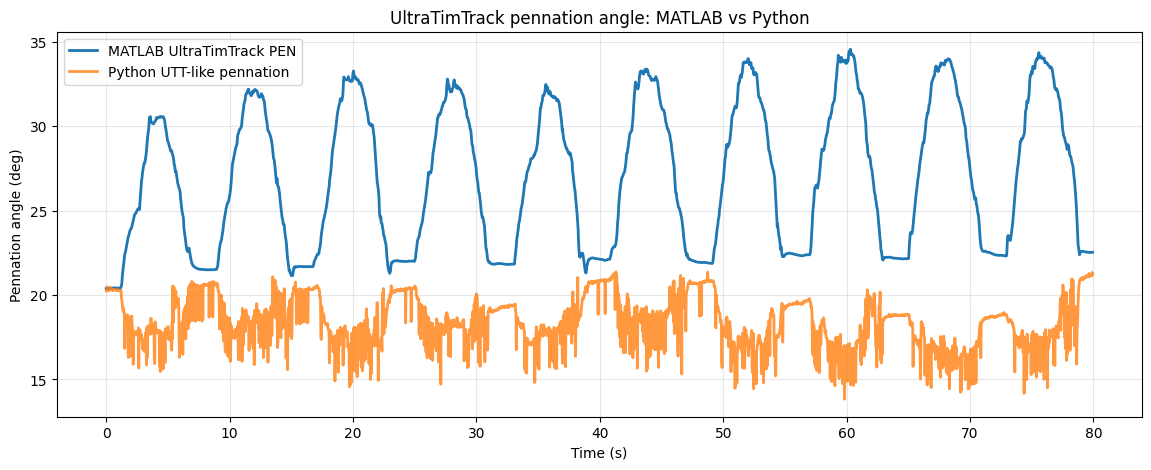

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(a_time, a_mat_utt_pennation, "-", linewidth=2, label="MATLAB UltraTimTrack PEN")
plt.plot(a_time, a_py_utt_pennation, "-", linewidth=2, alpha=0.8, label="Python UTT-like pennation")

plt.xlabel("Time (s)")
plt.ylabel("Pennation angle (deg)")
plt.title("UltraTimTrack pennation angle: MATLAB vs Python")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

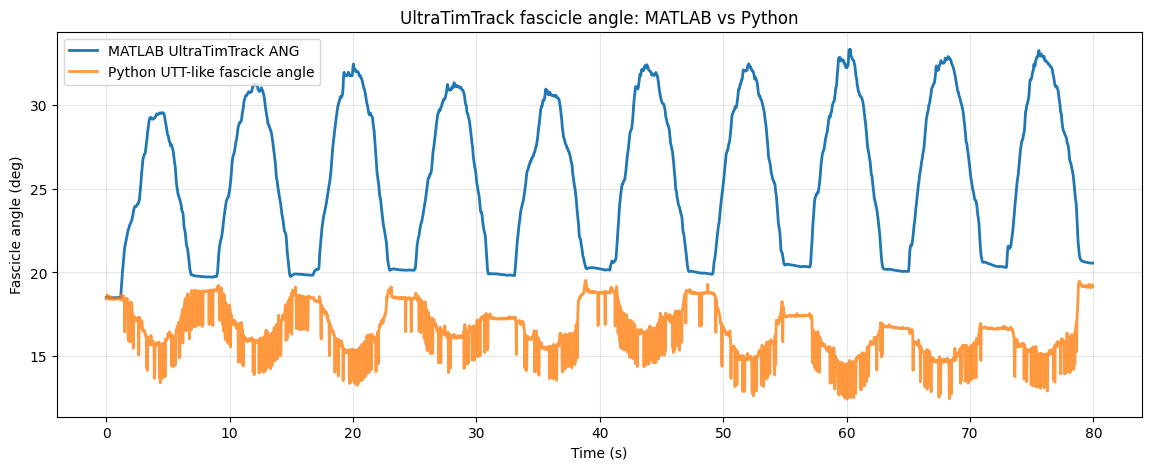

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(a_time, a_mat_utt_fascicle_angle, "-", linewidth=2, label="MATLAB UltraTimTrack ANG")
plt.plot(a_time, a_py_utt_fascicle_angle, "-", linewidth=2, alpha=0.8, label="Python UTT-like fascicle angle")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle angle (deg)")
plt.title("UltraTimTrack fascicle angle: MATLAB vs Python")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

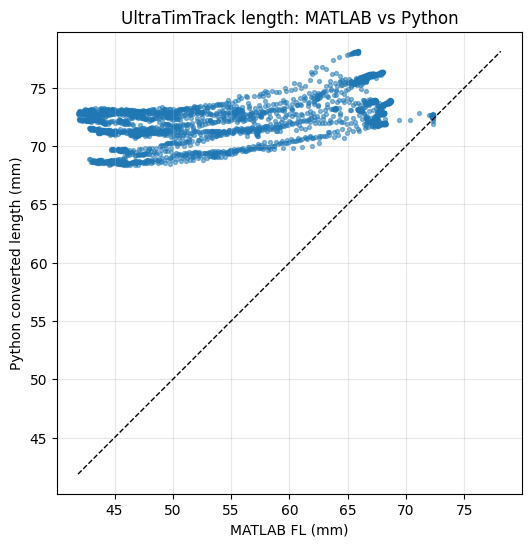

In [24]:
def scatter_compare(reference, estimate, title, xlabel="MATLAB", ylabel="Python"):
    ref, est, _ = valid_pair(reference, estimate)

    plt.figure(figsize=(6, 6))
    plt.scatter(ref, est, s=8, alpha=0.5)

    if len(ref) > 0:
        mn = min(np.nanmin(ref), np.nanmin(est))
        mx = max(np.nanmax(ref), np.nanmax(est))
        plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()


scatter_compare(
    a_mat_utt_length,
    a_py_utt_length_mm,
    "UltraTimTrack length: MATLAB vs Python",
    xlabel="MATLAB FL (mm)",
    ylabel="Python converted length (mm)",
)

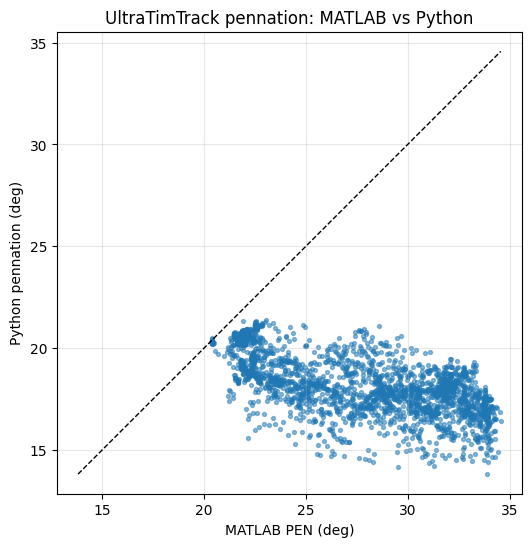

In [25]:
scatter_compare(
    a_mat_utt_pennation,
    a_py_utt_pennation,
    "UltraTimTrack pennation: MATLAB vs Python",
    xlabel="MATLAB PEN (deg)",
    ylabel="Python pennation (deg)",
)

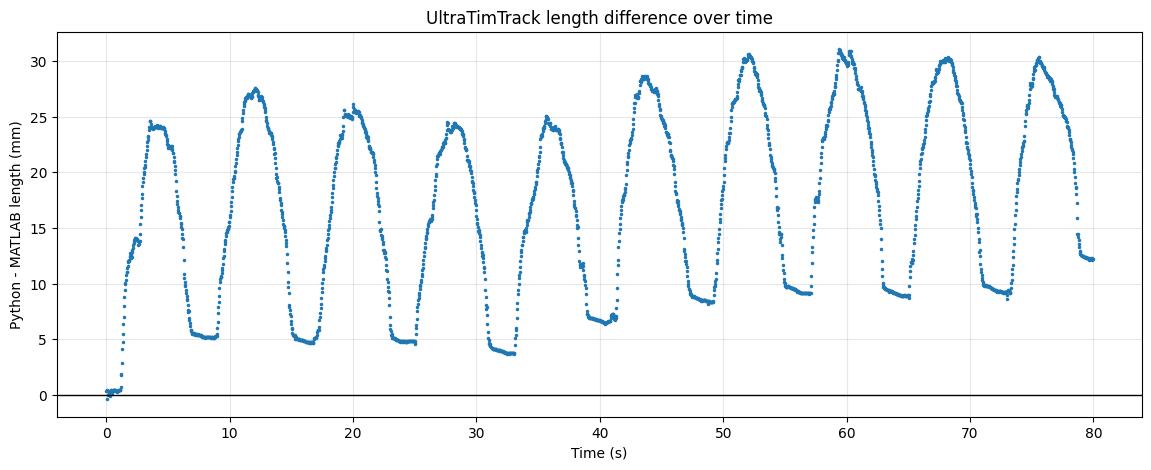

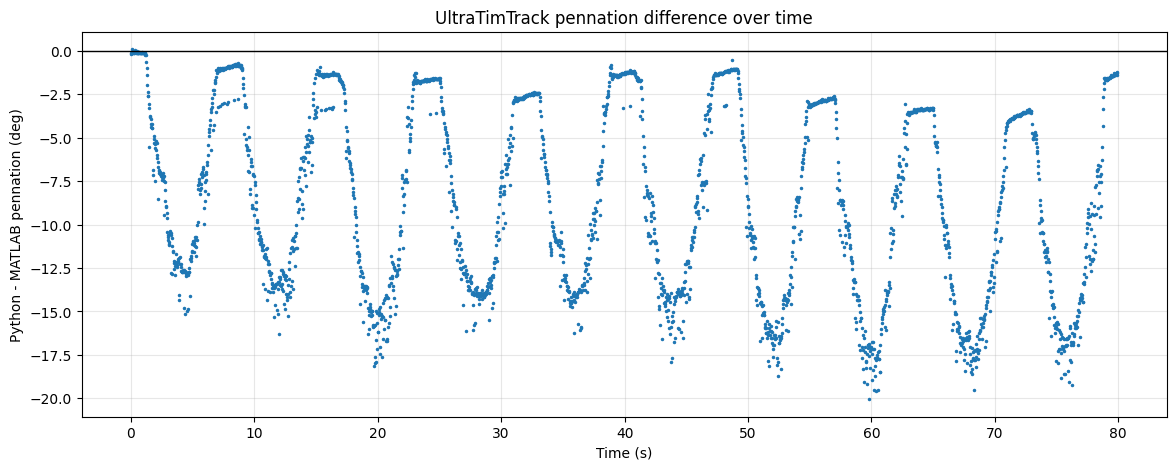

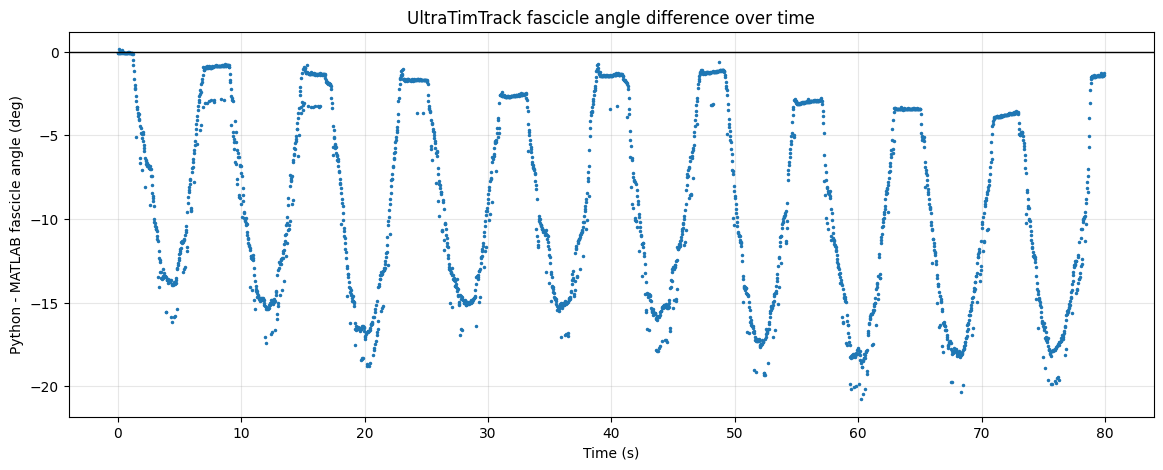

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(a_time, a_py_utt_length_mm - a_mat_utt_length, ".", markersize=3)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Python - MATLAB length (mm)")
plt.title("UltraTimTrack length difference over time")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))

plt.plot(a_time, a_py_utt_pennation - a_mat_utt_pennation, ".", markersize=3)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Python - MATLAB pennation (deg)")
plt.title("UltraTimTrack pennation difference over time")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))

plt.plot(a_time, a_py_utt_fascicle_angle - a_mat_utt_fascicle_angle, ".", markersize=3)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Python - MATLAB fascicle angle (deg)")
plt.title("UltraTimTrack fascicle angle difference over time")
plt.grid(True, alpha=0.3)
plt.show()

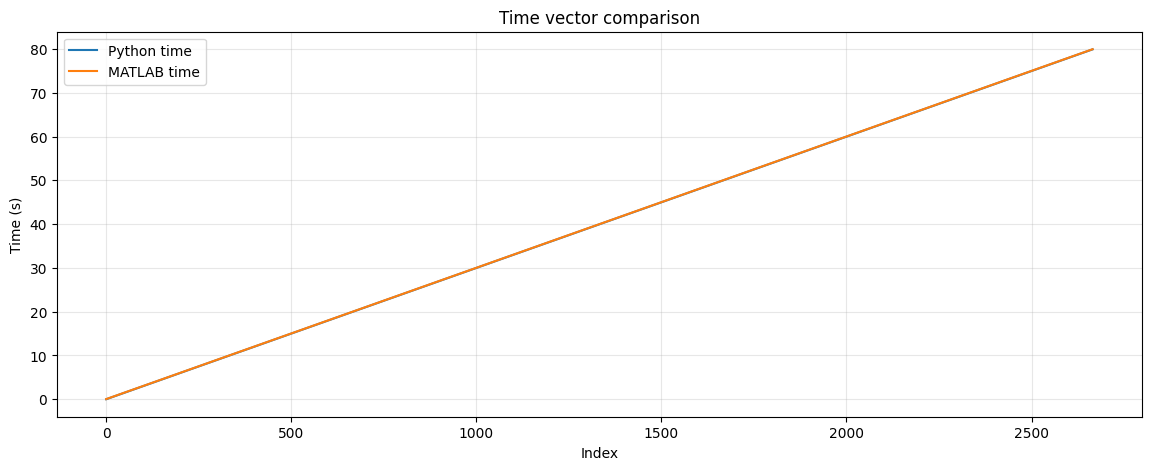

First Python times: [0.         0.0299931  0.0599862  0.08997931 0.11997241]
First MATLAB times: [0.02999309 0.05998618 0.08997928 0.11997236 0.14996547]
Mean time difference MATLAB - Python: 0.029979823


In [27]:
plt.figure(figsize=(14, 5))

plt.plot(a_py_time, label="Python time")
plt.plot(a_mat_time, label="MATLAB time")

plt.xlabel("Index")
plt.ylabel("Time (s)")
plt.title("Time vector comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("First Python times:", a_py_time[:5])
print("First MATLAB times:", a_mat_time[:5])
print("Mean time difference MATLAB - Python:", np.nanmean(a_mat_time - a_py_time))

In [28]:
np.savez(
    OUT_ALIGNED_NPZ,
    frame=a_py_time,
    py_time=a_py_time,
    mat_time=a_mat_time,

    mat_utt_length=a_mat_utt_length,
    py_utt_length_px=a_py_utt_length_px,
    py_utt_length_mm=a_py_utt_length_mm,

    mat_utt_pennation=a_mat_utt_pennation,
    py_utt_pennation=a_py_utt_pennation,

    mat_utt_fascicle_angle=a_mat_utt_fascicle_angle,
    py_utt_fascicle_angle=a_py_utt_fascicle_angle,

    mm_per_pixel=MM_PER_PIXEL,
    image_depth_mm=IMAGE_DEPTH_MM,
    image_depth_pixels=IMAGE_DEPTH_PIXELS,
)

print("Saved aligned arrays:", OUT_ALIGNED_NPZ)

Saved aligned arrays: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/matlab_vs_python_utt_aligned_arrays.npz


In [29]:
print("INTERPRETATION QUICK CHECK")
print("--------------------------")

print("Length:")
print("  If curves have similar shape but different scale, the issue is likely px-to-mm calibration.")
print("  If curves have different shape, the issue is likely tracking or Kalman weighting.")

print("\nPennation and fascicle angle:")
print("  If curves are offset by a constant, likely angle convention difference.")
print("  If one curve is inverted, likely sign convention or image y-axis convention.")
print("  If MATLAB is smooth and Python is too flat, Python KLT/Kalman may be too dominant.")
print("  If Python is too jittery, TimTrack measurement weight may be too strong.")

print("\nCurrent conversion:")
print(f"  MM_PER_PIXEL = {MM_PER_PIXEL}")
print(f"  IMAGE_DEPTH_MM = {IMAGE_DEPTH_MM}")
print(f"  IMAGE_DEPTH_PIXELS = {IMAGE_DEPTH_PIXELS}")

INTERPRETATION QUICK CHECK
--------------------------
Length:
  If curves have similar shape but different scale, the issue is likely px-to-mm calibration.
  If curves have different shape, the issue is likely tracking or Kalman weighting.

Pennation and fascicle angle:
  If curves are offset by a constant, likely angle convention difference.
  If one curve is inverted, likely sign convention or image y-axis convention.
  If MATLAB is smooth and Python is too flat, Python KLT/Kalman may be too dominant.
  If Python is too jittery, TimTrack measurement weight may be too strong.

Current conversion:
  MM_PER_PIXEL = 0.09021352313167261
  IMAGE_DEPTH_MM = 50.7
  IMAGE_DEPTH_PIXELS = 562


In [31]:
import json
import base64
from pathlib import Path

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Cherche automatiquement le notebook 17
matches = sorted(NOTEBOOKS_DIR.glob("17*.ipynb"))

if len(matches) == 0:
    raise FileNotFoundError(f"No notebook starting with '17' found in {NOTEBOOKS_DIR}")

if len(matches) > 1:
    print("Multiple matches found:")
    for p in matches:
        print("-", p.name)
    raise RuntimeError("Choose the exact notebook name manually.")

NOTEBOOK_PATH = matches[0]

EXPORT_DIR = Path.home() / "Desktop" / "NDORMS_notebook_exports" / NOTEBOOK_PATH.stem
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook:", NOTEBOOK_PATH)
print("Export folder:", EXPORT_DIR)

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    nb = json.load(f)

image_count = 0

for cell_idx, cell in enumerate(nb.get("cells", []), start=1):
    for output_idx, output in enumerate(cell.get("outputs", []), start=1):
        data = output.get("data", {})

        if "image/png" in data:
            image_count += 1

            img_data = data["image/png"]

            if isinstance(img_data, list):
                img_data = "".join(img_data)

            img_bytes = base64.b64decode(img_data)

            out_path = EXPORT_DIR / f"{NOTEBOOK_PATH.stem}_cell_{cell_idx:03d}_output_{output_idx:02d}.png"

            with open(out_path, "wb") as img_file:
                img_file.write(img_bytes)

            print("Saved:", out_path)

print(f"\nDone. Exported {image_count} images.")

Notebook: /Users/grosbedou/PycharmProjects/NDORMS/notebooks/17_compare_matlab_vs_python.ipynb
Export folder: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python/17_compare_matlab_vs_python_cell_017_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python/17_compare_matlab_vs_python_cell_018_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python/17_compare_matlab_vs_python_cell_019_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python/17_compare_matlab_vs_python_cell_020_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python/17_compare_matlab_vs_python_cell_021_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/17_compare_matlab_vs_python/17_compare_matlab_vs_python_cell_022_output_01.png
Save